#### Imports & Setups

In [1]:
import os
import yaml
import time
import uuid
import json
from pathlib import Path
from typing import TypedDict
from dotenv import load_dotenv
from langgraph_utils import console
from pydantic import BaseModel, Field
from IPython.display import clear_output
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI


params_config = yaml.safe_load(Path("./configs/params.yaml").read_text())
prompts_config = yaml.safe_load(Path("./configs/prompts.yaml").read_text())

load_dotenv()


True

#### State

In [2]:
class JokeState(TypedDict):
    character: str
    topic: str
    joke: str
    explanation: str

#### Model

In [3]:
model = ChatGoogleGenerativeAI(**params_config["llm"])

#### Output Schemas

In [4]:
class JokeSchema(BaseModel):
    joke: str = Field(description=params_config["JokeSchema"]["description"])


class ExplanationSchema(BaseModel):
    explanation: str = Field(description=params_config["ExplanationSchema"]["description"])


#### Node Functions

In [5]:
def generate_joke(state: JokeState):
    joke_prompt = ChatPromptTemplate(
        [
            ("system", prompts_config["generate_joke"]["system_prompt"]),
            ("user", prompts_config["generate_joke"]["user_prompt"]),
        ]
    )

    joke_model = model.with_structured_output(JokeSchema)
    chain = joke_prompt | joke_model

    with console.status("Generate Joke...", spinner="dots"):
        res = chain.invoke(
            {
                "character": state["character"],
                "topic": state["topic"],
            }
        )
    clear_output(wait=True)
    return {"joke": res.joke}


def simulate_latency(state: JokeState):

    with console.status("Connecting...", spinner="dots"):
        time.sleep(10)
    clear_output(wait=True)
    return state


def generate_explanation(state: JokeState):
    explanation_prompt = ChatPromptTemplate(
        [
            ("system", prompts_config["generate_explanation"]["system_prompt"]),
            ("user", prompts_config["generate_explanation"]["user_prompt"]),
        ]
    )

    explanation_model = model.with_structured_output(ExplanationSchema)
    chain = explanation_prompt | explanation_model

    with console.status("Generate Explanation...", spinner="dots"):
        res = chain.invoke(
            {
                "character": state["character"],
                "topic": state["topic"],
                "joke": state["joke"],
            }
        )
    clear_output(wait=False)
    console.print("Workflow executed successfully!")
    return {"explanation": res.explanation}


#### Init Graph

In [6]:
graph = StateGraph(JokeState)


#### Add Nodes

In [7]:
graph.add_node("generate_joke", generate_joke)
graph.add_node("simulate_latency", simulate_latency)
graph.add_node("generate_explanation", generate_explanation)

#### Add Edges

In [8]:
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "simulate_latency")
graph.add_edge("simulate_latency", "generate_explanation")
graph.add_edge("generate_explanation", END)

#### Compilation

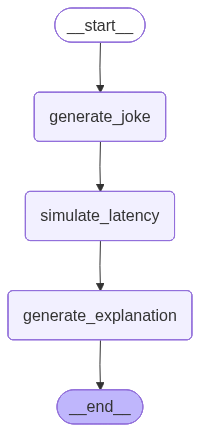

In [9]:
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

#### Config

In [10]:
cs_id = uuid.uuid1().int
cs_config = {"configurable": {"thread_id": cs_id}}
console.print(cs_config)

{'configurable': {'thread_id': 277591444769552116663603470018052423641}}


#### Execution

In [11]:
try:
    final_state = workflow.invoke(
        {
            "character": "Shashi Tharoor",
            "topic": "Counter Strike",
        },
        config=cs_config,
    )
except KeyboardInterrupt as e:
    print(str(e))

⠋ Connecting.....



In [12]:
state_history = list(workflow.get_state_history(cs_config))
console.print(state_history)

[
    StateSnapshot(
        values={
            'character': 'Shashi Tharoor',
            'topic': 'Counter Strike',
            'joke': "My dear friends, mastering the intricate, nay, labyrinthine nomenclature of 'rush B' and 'eco 
round' in Counter-Strike proves almost as formidable an intellectual exercise as navigating the more bewildering 
lexicons of parliamentary discourse. Frankly, the only 'AWP' I'm truly adept with is 'Academic Word Power'!"
        },
        next=('simulate_latency',),
        config={
            'configurable': {
                'thread_id': '277591444769552116663603470018052423641',
                'checkpoint_ns': '',
                'checkpoint_id': '1f170b6d-4f9c-6894-8001-595284aac404'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-06-25T16:56:38.469402+00:00',
        parent_config={
            'configurable': {
                'thread_id': '277591444769552116663603470018052423641

In [14]:
final_state_resume = workflow.invoke(None, config=cs_config)
console.print_json(data=final_state_resume)

{
  "character": "Shashi Tharoor",
  "topic": "Counter Strike",
  "joke": "My dear friends, mastering the intricate, nay, labyrinthine nomenclature of 'rush B' and 'eco round' in Counter-Strike proves almost as formidable an intellectual exercise as navigating the more bewildering lexicons of parliamentary discourse. Frankly, the only 'AWP' I'm truly adept with is 'Academic Word Power'!",
  "explanation": "The joke leverages Shashi Tharoor's famously verbose and intellectual style to humorously address a niche topic. The setup elaborately compares mastering Counter-Strike terms like 'rush B' (a team strategy) and 'eco round' (saving money) to navigating 'parliamentary discourse,' an exaggerated contrast that highlights his erudite persona. The humor is primarily wordplay and self-deprecating irony. The punchline, \"the only 'AWP' I'm truly adept with is 'Academic Word Power',\" brilliantly twists 'AWP' (a powerful sniper rifle in the game) into a self-referential joke about his renowne

In [15]:
state_history = list(workflow.get_state_history(cs_config))
console.print(state_history)

[
    StateSnapshot(
        values={
            'character': 'Shashi Tharoor',
            'topic': 'Counter Strike',
            'joke': "My dear friends, mastering the intricate, nay, labyrinthine nomenclature of 'rush B' and 'eco 
round' in Counter-Strike proves almost as formidable an intellectual exercise as navigating the more bewildering 
lexicons of parliamentary discourse. Frankly, the only 'AWP' I'm truly adept with is 'Academic Word Power'!",
            'explanation': 'The joke leverages Shashi Tharoor\'s famously verbose and intellectual style to humorously 
address a niche topic. The setup elaborately compares mastering Counter-Strike terms like \'rush B\' (a team strategy) 
and \'eco round\' (saving money) to navigating \'parliamentary discourse,\' an exaggerated contrast that highlights his 
erudite persona. The humor is primarily wordplay and self-deprecating irony. The punchline, "the only \'AWP\' I\'m truly
adept with is \'Academic Word Power\'," brilliantly twists

In [16]:
os.makedirs("files", exist_ok=True)

with open("files/2-fault_tolerance_joke.txt", "w") as f:
    f.write(f"Joke:\n{final_state_resume['joke']}\n\nExplanation:\n{final_state_resume['explanation']}")


with open("files/2-fault_tolerance_state_history.json", "w") as f:
    json.dump(state_history, f, indent=4)
